# ============================================================
# BrainTumorVQA Phase 01 (Pretrained MONAI BraTS 2D Segmentation)
# RSNA 2D Mask Generation & Visualization
# Google Colab Free Safe Version
# ============================================================


# Dual Environment Compatibility Setup & Install Required Libraries


In [ ]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

!pip install -q monai nibabel huggingface_hub kaggle opencv-python-headless matplotlib pandas tqdm

import os
import cv2
import csv
import json
import time
import zipfile
import shutil
import random
import subprocess
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import torch
from torch.amp import autocast

import monai
from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

from huggingface_hub import hf_hub_download

from google.colab import drive, userdata

print("Libraries loaded successfully.")
print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.9 MB/s eta 0:00:00
Libraries loaded successfully.
PyTorch: 2.10.0+cu128
MONAI: 1.5.2
CUDA available: True
GPU: Tesla T4


# Mount Google Drive and Main Configuration

In [ ]:
# drive.mount("/content/drive")

# Change only this project path if needed.
PROJECT_DRIVE_DIR = PROJECT_ROOT

PHASE1_DIR = PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats"
MASK_SAVE_DIR = PHASE1_DIR / "generated_masks_rsna_2d"
LOG_DIR = PHASE1_DIR / "logs"
MODEL_DIR = PHASE1_DIR / "pretrained_models"
PATIENT_DONE_DIR = LOG_DIR / "patient_done"
PATIENT_MANIFEST_DIR = LOG_DIR / "patient_manifests"
TEMP_LOCAL_DIR = TEMP_DIR / "phase1_temp")

for directory in [
    PHASE1_DIR,
    MASK_SAVE_DIR,
    LOG_DIR,
    MODEL_DIR,
    PATIENT_DONE_DIR,
    PATIENT_MANIFEST_DIR,
    TEMP_LOCAL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Your current RSNA-BraTS 2D Kaggle dataset.
DATASET_ID = "snish9/rsnabrats20212d"
LOCAL_DATASET_DIR = TEMP_DIR / "rsna_brats_2021_2d")
DRIVE_DATASET_ZIP = PHASE1_DIR / "dataset_cache" / "rsnabrats20212d.zip"
DRIVE_DATASET_ZIP.parent.mkdir(parents=True, exist_ok=True)

# MONAI pretrained BraTS model.
HF_REPO_ID = "MONAI/brats_mri_segmentation"

# Fixed revision for reproducibility.
# This revision was visible in the Hugging Face repo history for bundle version 0.5.3.
HF_REVISION = "6ea5b85f04151c71e5599a6f31000e5b042e8d80"

MODEL_PT_PATH = MODEL_DIR / "models" / "model.pt"

# Output / tracking files.
RUN_CONFIG_PATH = LOG_DIR / "phase1_run_config.json"
SKIP_LOG_PATH = LOG_DIR / "missing_or_failed_slices.json"
GLOBAL_MANIFEST_PATH = LOG_DIR / "global_mask_manifest.csv"
SUMMARY_PATH = LOG_DIR / "phase1_summary.json"
SAMPLE_FIG_PATH = LOG_DIR / "sample_mask_visualization.png"

# Inference settings.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

# MONAI official config uses ROI depth 160.
# If Colab GPU runs out of memory, code automatically retries smaller depths.
ROI_DEPTH_CANDIDATES = [160, 128, 96, 64]

SW_BATCH_SIZE = 1
SW_OVERLAP = 0.50

# Keep False for full Phase 1.
# If True, saves masks only for CSV rows where tumor_slice == 1.
GENERATE_ONLY_TUMOR_SLICES = False

# Keep False for resume safety.
OVERWRITE_EXISTING_MASKS = False

# For a quick smoke test, set this to 2 or 3.
# For full Phase 1, keep None.
MAX_PATIENTS_PER_RUN = None

# RSNA PNG image size.
IMAGE_SIZE = 240

# MONAI model input channel order:
# channel 0 = T1ce, channel 1 = T1, channel 2 = T2, channel 3 = FLAIR
MODEL_MODALITY_ORDER = ["t1ce", "t1", "t2", "flair"]

# Final BraTS-style label values for generated PNG masks.
# 0 = background
# 1 = tumor core except enhancing tumor, approximately NCR/NET
# 2 = edema
# 4 = enhancing tumor
LABEL_NAMES = {
    0: "Background",
    1: "Tumor core / NCR-NET approximation",
    2: "Edema",
    4: "Enhancing tumor",
}

print("Project directory:", PROJECT_DRIVE_DIR)
print("Phase 1 directory:", PHASE1_DIR)
print("Mask save directory:", MASK_SAVE_DIR)
print("Device:", DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Phase 1 directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats
Mask save directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d
Device: cuda


# Persistence Helpers

In [ ]:
def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def atomic_write_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)
    os.replace(temp_path, path)


def read_json(path: Path, default):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def atomic_write_csv(path: Path, rows: list, fieldnames: list):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    os.replace(temp_path, path)


def append_csv(path: Path, rows: list, fieldnames: list):
    if not rows:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    file_exists = path.exists()

    with open(path, "a", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)


def safe_copy_to_drive(local_path: Path, final_drive_path: Path):
    """
    Safer Drive write:
    write/copy to temporary file first, then atomic rename.
    """
    final_drive_path.parent.mkdir(parents=True, exist_ok=True)
    temp_drive_path = final_drive_path.with_suffix(final_drive_path.suffix + ".tmp")
    shutil.copy2(local_path, temp_drive_path)
    os.replace(temp_drive_path, final_drive_path)


def save_png_safely(mask: np.ndarray, final_drive_path: Path, local_temp_dir: Path):
    local_temp_dir.mkdir(parents=True, exist_ok=True)
    local_temp_path = local_temp_dir / final_drive_path.name

    success = cv2.imwrite(str(local_temp_path), mask)
    if not success:
        return False

    try:
        safe_copy_to_drive(local_temp_path, final_drive_path)
        local_temp_path.unlink(missing_ok=True)
        return True
    except Exception:
        local_temp_path.unlink(missing_ok=True)
        raise


run_config = {
    "created_at": now_string(),
    "phase": "phase_1_segmentation_mask_generation",
    "dataset_id": DATASET_ID,
    "hf_repo_id": HF_REPO_ID,
    "hf_revision": HF_REVISION,
    "model_type": "MONAI SegResNet pretrained BraTS MRI segmentation",
    "model_input_order": MODEL_MODALITY_ORDER,
    "model_output_channels": {
        "0": "Tumor core",
        "1": "Whole tumor",
        "2": "Enhancing tumor",
    },
    "generated_mask_labels": LABEL_NAMES,
    "mask_save_dir": str(MASK_SAVE_DIR),
    "generate_only_tumor_slices": GENERATE_ONLY_TUMOR_SLICES,
    "overwrite_existing_masks": OVERWRITE_EXISTING_MASKS,
    "roi_depth_candidates": ROI_DEPTH_CANDIDATES,
    "sw_overlap": SW_OVERLAP,
    "use_amp": USE_AMP,
}

atomic_write_json(RUN_CONFIG_PATH, run_config)
print("Run config saved:", RUN_CONFIG_PATH)


Run config saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/phase1_run_config.json


# Download or Restore RSNA-BraTS 2021 2D Dataset

In [ ]:
def has_valid_dataset_root(path: Path):
    return (
        path.exists()
        and (path / "target.csv").exists()
        and (path / "flair").exists()
        and (path / "t1").exists()
        and (path / "t1ce").exists()
        and (path / "t2").exists()
    )


def find_dataset_root(search_root: Path):
    if has_valid_dataset_root(search_root):
        return search_root

    candidates = []
    for csv_path in search_root.rglob("target.csv"):
        parent = csv_path.parent
        if has_valid_dataset_root(parent):
            candidates.append(parent)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find dataset root under {search_root}. "
            "Expected target.csv plus flair/t1/t1ce/t2 folders."
        )

    return candidates[0]


def download_or_restore_dataset():
    if has_valid_dataset_root(LOCAL_DATASET_DIR):
        print("Dataset already exists locally:", LOCAL_DATASET_DIR)
        return find_dataset_root(LOCAL_DATASET_DIR)

    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    local_zip_path = LOCAL_DATASET_DIR / "rsnabrats20212d.zip"

    if DRIVE_DATASET_ZIP.exists():
        print("Restoring dataset zip from Google Drive cache...")
        shutil.copy2(DRIVE_DATASET_ZIP, local_zip_path)
    else:
        print("Dataset zip not found in Drive cache. Downloading from Kaggle...")

        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key = userdata.get("KAGGLE_KEY")

        if not kaggle_username or not kaggle_key:
            raise RuntimeError(
                "Kaggle credentials missing. Add KAGGLE_USERNAME and KAGGLE_KEY "
                "to Colab Secrets and enable access for this notebook."
            )

        os.environ["KAGGLE_USERNAME"] = kaggle_username
        os.environ["KAGGLE_KEY"] = kaggle_key

        subprocess.run(
            ["kaggle", "datasets", "download", "-d", DATASET_ID, "-p", str(LOCAL_DATASET_DIR)],
            check=True,
        )

        zip_files = sorted(LOCAL_DATASET_DIR.glob("*.zip"), key=lambda p: p.stat().st_size, reverse=True)
        if not zip_files:
            raise FileNotFoundError("Kaggle download completed, but no zip file was found.")

        downloaded_zip = zip_files[0]
        downloaded_zip.rename(local_zip_path)

        print("Caching dataset zip to Google Drive for future sessions...")
        safe_copy_to_drive(local_zip_path, DRIVE_DATASET_ZIP)

    print("Unzipping dataset locally in /content...")
    with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)

    dataset_root = find_dataset_root(LOCAL_DATASET_DIR)
    print("Dataset root:", dataset_root)
    return dataset_root


DATASET_ROOT = download_or_restore_dataset()
CSV_PATH = DATASET_ROOT / "target.csv"

print("CSV path:", CSV_PATH)
print("Dataset folders:")
for folder in ["flair", "t1", "t1ce", "t2"]:
    print(folder, "files:", len(list((DATASET_ROOT / folder).glob("*.png"))))


Dataset already exists locally: /content/rsna_brats_2021_2d
CSV path: /content/rsna_brats_2021_2d/target.csv
Dataset folders:
flair files: 79864
t1 files: 79864
t1ce files: 79864
t2 files: 79864


# Validate Dataset Structure

In [ ]:
def load_target_dataframe(csv_path: Path):
    df = pd.read_csv(csv_path, dtype={"BraTS21ID": str, "image_id": str, "tumor_slice": int})
    df["BraTS21ID"] = df["BraTS21ID"].astype(str).str.zfill(5)
    df["image_id"] = df["image_id"].astype(str).str.zfill(3)
    df["slice_int"] = df["image_id"].astype(int)
    df["unique_id"] = df["BraTS21ID"] + "_" + df["image_id"]
    df = df.sort_values(["BraTS21ID", "slice_int"]).reset_index(drop=True)
    return df


def expected_png_path(dataset_root: Path, modality: str, patient_id: str, slice_id: str):
    return dataset_root / modality / f"{modality}_BraTS2021_{patient_id}_{slice_id}.png"


df_all = load_target_dataframe(CSV_PATH)

print("CSV rows:", len(df_all))
print("Unique patients:", df_all["BraTS21ID"].nunique())
print("Columns:", df_all.columns.tolist())
print(df_all.head())
print("\ntumor_slice distribution:")
print(df_all["tumor_slice"].value_counts())

missing_by_modality = {}
for modality in ["flair", "t1", "t1ce", "t2"]:
    missing = []
    for row in df_all.itertuples(index=False):
        path = expected_png_path(DATASET_ROOT, modality, row.BraTS21ID, row.image_id)
        if not path.exists():
            missing.append(row.unique_id)
    missing_by_modality[modality] = missing
    print(f"{modality}: missing {len(missing)} / {len(df_all)}")

dataset_validation = {
    "validated_at": now_string(),
    "csv_rows": int(len(df_all)),
    "unique_patients": int(df_all["BraTS21ID"].nunique()),
    "tumor_slice_distribution": {
        str(k): int(v) for k, v in df_all["tumor_slice"].value_counts().to_dict().items()
    },
    "missing_by_modality_count": {
        modality: len(ids) for modality, ids in missing_by_modality.items()
    },
    "first_missing_examples": {
        modality: ids[:10] for modality, ids in missing_by_modality.items()
    },
}

atomic_write_json(LOG_DIR / "dataset_validation.json", dataset_validation)
print("\nDataset validation saved.")


CSV rows: 79921
Unique patients: 1251
Columns: ['BraTS21ID', 'image_id', 'tumor_slice', 'slice_int', 'unique_id']
  BraTS21ID image_id  tumor_slice  slice_int  unique_id
0     00000      049            0         49  00000_049
1     00000      050            0         50  00000_050
2     00000      051            0         51  00000_051
3     00000      052            1         52  00000_052
4     00000      053            1         53  00000_053

tumor_slice distribution:
tumor_slice
1    60697
0    19224
Name: count, dtype: int64
flair: missing 57 / 79921
t1: missing 57 / 79921
t1ce: missing 57 / 79921
t2: missing 57 / 79921

Dataset validation saved.


# Download or Load MONAI Pretrained BraTS Model

In [ ]:
def download_monai_bundle_if_needed():
    if MODEL_PT_PATH.exists():
        print("MONAI model already cached in Drive:", MODEL_PT_PATH)
        return MODEL_PT_PATH

    print("Downloading MONAI BraTS pretrained model from Hugging Face...")

    # Download model.
    model_path = hf_hub_download(
        repo_id=HF_REPO_ID,
        filename="models/model.pt",
        revision=HF_REVISION,
        local_dir=str(MODEL_DIR),
    )

    # Download useful config/docs for reproducibility.
    for filename in [
        "configs/inference.json",
        "configs/metadata.json",
        "docs/README.md",
        "LICENSE",
    ]:
        try:
            hf_hub_download(
                repo_id=HF_REPO_ID,
                filename=filename,
                revision=HF_REVISION,
                local_dir=str(MODEL_DIR),
            )
        except Exception as error:
            print(f"Warning: could not download {filename}: {error}")

    print("Model downloaded:", model_path)
    return Path(model_path)


def clean_state_dict_keys(state_dict):
    cleaned = {}
    prefixes = ["module.", "network.", "model."]

    for key, value in state_dict.items():
        new_key = key
        changed = True

        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def extract_model_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for candidate_key in ["model", "model_state_dict", "state_dict", "network"]:
            if candidate_key in checkpoint and isinstance(checkpoint[candidate_key], dict):
                print(f"Using checkpoint key: {candidate_key}")
                return checkpoint[candidate_key]

        # If it looks like a raw state_dict.
        if all(isinstance(key, str) for key in checkpoint.keys()):
            print("Using checkpoint as raw state_dict.")
            return checkpoint

    raise ValueError("Could not extract model state_dict from checkpoint.")


def build_monai_brats_model(device):
    model = SegResNet(
        blocks_down=[1, 2, 2, 4],
        blocks_up=[1, 1, 1],
        init_filters=16,
        in_channels=4,
        out_channels=3,
        dropout_prob=0.2,
    )
    return model.to(device)


model_path = download_monai_bundle_if_needed()

model = build_monai_brats_model(DEVICE)

try:
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(model_path, map_location=DEVICE)

state_dict = extract_model_state_dict(checkpoint)
state_dict = clean_state_dict_keys(state_dict)

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

if missing_keys:
    print("Missing keys:", missing_keys[:10], "..." if len(missing_keys) > 10 else "")
if unexpected_keys:
    print("Unexpected keys:", unexpected_keys[:10], "..." if len(unexpected_keys) > 10 else "")

if missing_keys or unexpected_keys:
    print("Warning: model loaded with non-strict matching. Validate outputs carefully.")
else:
    print("Model loaded with clean key match.")

model.eval()
torch.backends.cudnn.benchmark = True

total_params = sum(param.numel() for param in model.parameters())
print("Total model parameters:", f"{total_params:,}")
print("Model ready on:", DEVICE)


MONAI model already cached in Drive: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/pretrained_models/models/model.pt
Using checkpoint as raw state_dict.
Model loaded with clean key match.
Total model parameters: 4,702,227
Model ready on: cuda


# Patient Volume Builder
# RSNA PNG slices → pseudo-3D BraTS volume

In [ ]:
def read_grayscale_png(path: Path, image_size: int = 240):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    if image.shape != (image_size, image_size):
        image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

    return image.astype(np.float32)


def normalize_nonzero_channel(volume_3d: np.ndarray):
    """
    Approximation of MONAI NormalizeIntensityd(nonzero=True, channel_wise=True).
    volume_3d shape: [H, W, D]
    """
    volume_3d = volume_3d.astype(np.float32)
    output = np.zeros_like(volume_3d, dtype=np.float32)

    nonzero_mask = volume_3d != 0
    if not np.any(nonzero_mask):
        return output

    values = volume_3d[nonzero_mask]
    mean = values.mean()
    std = values.std()

    if std < 1e-8:
        std = 1.0

    output[nonzero_mask] = (volume_3d[nonzero_mask] - mean) / std
    return output


def build_patient_volume(df_patient: pd.DataFrame, dataset_root: Path):
    """
    Returns:
        volume_tensor: [1, 4, H, W, D]
        slice_info: list of dicts
    """
    df_patient = df_patient.sort_values("slice_int").reset_index(drop=True)

    channel_volumes = []
    slice_info = []

    for modality in MODEL_MODALITY_ORDER:
        modality_slices = []

        for row in df_patient.itertuples(index=False):
            path = expected_png_path(dataset_root, modality, row.BraTS21ID, row.image_id)
            image = read_grayscale_png(path, IMAGE_SIZE)

            if image is None:
                image = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)

            modality_slices.append(image)

        volume = np.stack(modality_slices, axis=-1)  # [H, W, D]
        volume = normalize_nonzero_channel(volume)
        channel_volumes.append(volume)

    for row in df_patient.itertuples(index=False):
        missing_modalities = []
        for modality in ["flair", "t1", "t1ce", "t2"]:
            path = expected_png_path(dataset_root, modality, row.BraTS21ID, row.image_id)
            if not path.exists():
                missing_modalities.append(modality)

        slice_info.append(
            {
                "patient_id": row.BraTS21ID,
                "slice_id": row.image_id,
                "slice_int": int(row.slice_int),
                "unique_id": row.unique_id,
                "tumor_slice": int(row.tumor_slice),
                "missing_modalities": missing_modalities,
            }
        )

    volume_np = np.stack(channel_volumes, axis=0)  # [C, H, W, D]
    volume_tensor = torch.from_numpy(volume_np).unsqueeze(0).float()  # [1, C, H, W, D]

    return volume_tensor, slice_info


def get_expected_mask_path(unique_id: str):
    return MASK_SAVE_DIR / f"{unique_id}.png"


print("Volume builder ready.")


Volume builder ready.


# MONAI Inference and Label Conversion

In [ ]:
def run_sliding_window_with_oom_fallback(volume_tensor: torch.Tensor):
    """
    Input:  [1, 4, H, W, D]
    Output: [3, H, W, D] boolean numpy array
    """
    volume_tensor = volume_tensor.to(DEVICE, non_blocking=True)

    last_error = None

    for roi_depth in ROI_DEPTH_CANDIDATES:
        roi_size = (IMAGE_SIZE, IMAGE_SIZE, roi_depth)

        try:
            with torch.no_grad():
                with autocast(device_type="cuda", enabled=USE_AMP):
                    logits = sliding_window_inference(
                        inputs=volume_tensor,
                        roi_size=roi_size,
                        sw_batch_size=SW_BATCH_SIZE,
                        predictor=model,
                        overlap=SW_OVERLAP,
                        mode="gaussian",
                    )
                    probs = torch.sigmoid(logits)
                    pred = probs > 0.5

            pred_np = pred.squeeze(0).detach().cpu().numpy().astype(bool)  # [3, H, W, D]

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

            return pred_np, roi_depth

        except RuntimeError as error:
            last_error = error
            error_text = str(error).lower()

            if "out of memory" in error_text or "cuda" in error_text:
                print(f"CUDA issue with ROI depth {roi_depth}. Retrying smaller ROI...")
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()
                time.sleep(2)
                continue

            raise error

    raise RuntimeError(f"All ROI depths failed. Last error: {last_error}")


def monai_regions_to_brats_mask(pred_regions: np.ndarray):
    """
    MONAI output channels:
        channel 0 = TC, tumor core
        channel 1 = WT, whole tumor
        channel 2 = ET, enhancing tumor

    Convert to BraTS-style single mask:
        0 = background
        1 = tumor core except ET, approximation for NCR/NET
        2 = edema, WT minus TC
        4 = enhancing tumor
    """
    tc = pred_regions[0]  # [H, W, D]
    wt = pred_regions[1]
    et = pred_regions[2]

    mask = np.zeros(wt.shape, dtype=np.uint8)

    # Priority order matters.
    mask[wt] = 2
    mask[tc] = 1
    mask[et] = 4

    return mask


print("Inference functions ready.")


Inference functions ready.


# Patient-Level Resume-Safe Mask Generation

In [ ]:
MANIFEST_FIELDS = [
    "patient_id",
    "slice_id",
    "unique_id",
    "tumor_slice_csv",
    "mask_path",
    "unique_mask_values",
    "non_background_pixels",
    "missing_modalities",
    "roi_depth_used",
    "saved_at",
]


def patient_done_path(patient_id: str):
    return PATIENT_DONE_DIR / f"{patient_id}.json"


def patient_manifest_path(patient_id: str):
    return PATIENT_MANIFEST_DIR / f"{patient_id}.csv"


def expected_slice_infos_to_save(slice_info: list):
    selected = []
    for item in slice_info:
        if item["missing_modalities"]:
            continue
        if GENERATE_ONLY_TUMOR_SLICES and item["tumor_slice"] != 1:
            continue
        selected.append(item)
    return selected


def patient_already_complete(patient_id: str, expected_infos: list):
    done_path = patient_done_path(patient_id)
    if not done_path.exists():
        return False

    if OVERWRITE_EXISTING_MASKS:
        return False

    for item in expected_infos:
        if not get_expected_mask_path(item["unique_id"]).exists():
            return False

    return True


def process_one_patient(patient_id: str, df_patient: pd.DataFrame):
    started_at = time.time()

    volume_tensor, slice_info = build_patient_volume(df_patient, DATASET_ROOT)
    expected_infos = expected_slice_infos_to_save(slice_info)

    if patient_already_complete(patient_id, expected_infos):
        return {
            "patient_id": patient_id,
            "status": "skipped_already_complete",
            "saved_count": 0,
            "missing_count": 0,
            "roi_depth_used": None,
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    missing_infos = [item for item in slice_info if item["missing_modalities"]]

    if len(expected_infos) == 0:
        atomic_write_json(
            patient_done_path(patient_id),
            {
                "patient_id": patient_id,
                "status": "no_valid_slices_to_save",
                "finished_at": now_string(),
                "missing_count": len(missing_infos),
            },
        )
        return {
            "patient_id": patient_id,
            "status": "no_valid_slices_to_save",
            "saved_count": 0,
            "missing_count": len(missing_infos),
            "roi_depth_used": None,
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    pred_regions, roi_depth_used = run_sliding_window_with_oom_fallback(volume_tensor)
    mask_volume = monai_regions_to_brats_mask(pred_regions)  # [H, W, D]

    rows = []
    saved_count = 0
    failed_saves = []
    skipped_existing = 0

    for depth_index, item in enumerate(slice_info):
        if item["missing_modalities"]:
            continue

        if GENERATE_ONLY_TUMOR_SLICES and item["tumor_slice"] != 1:
            continue

        mask_path = get_expected_mask_path(item["unique_id"])

        if mask_path.exists() and not OVERWRITE_EXISTING_MASKS:
            skipped_existing += 1
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = mask_volume[:, :, depth_index]
        else:
            mask = mask_volume[:, :, depth_index]
            try:
                ok = save_png_safely(
                    mask=mask,
                    final_drive_path=mask_path,
                    local_temp_dir=TEMP_LOCAL_DIR / "png_write",
                )
                if not ok:
                    failed_saves.append(item["unique_id"])
                    continue
                saved_count += 1
            except Exception:
                failed_saves.append(item["unique_id"])
                print(f"Failed saving {item['unique_id']}")
                traceback.print_exc()
                continue

        unique_values = np.unique(mask).astype(int).tolist()
        non_background_pixels = int(np.sum(mask > 0))

        rows.append(
            {
                "patient_id": item["patient_id"],
                "slice_id": item["slice_id"],
                "unique_id": item["unique_id"],
                "tumor_slice_csv": item["tumor_slice"],
                "mask_path": str(mask_path),
                "unique_mask_values": json.dumps(unique_values),
                "non_background_pixels": non_background_pixels,
                "missing_modalities": json.dumps(item["missing_modalities"]),
                "roi_depth_used": roi_depth_used,
                "saved_at": now_string(),
            }
        )

    atomic_write_csv(patient_manifest_path(patient_id), rows, MANIFEST_FIELDS)

    done_payload = {
        "patient_id": patient_id,
        "status": "complete" if not failed_saves else "complete_with_save_failures",
        "finished_at": now_string(),
        "total_csv_slices": int(len(df_patient)),
        "expected_saved_or_existing": int(len(expected_infos)),
        "newly_saved_count": int(saved_count),
        "skipped_existing_count": int(skipped_existing),
        "manifest_rows": int(len(rows)),
        "missing_count": int(len(missing_infos)),
        "failed_saves": failed_saves,
        "roi_depth_used": roi_depth_used,
        "elapsed_sec": round(time.time() - started_at, 2),
    }

    atomic_write_json(patient_done_path(patient_id), done_payload)

    return {
        "patient_id": patient_id,
        "status": done_payload["status"],
        "saved_count": saved_count,
        "skipped_existing": skipped_existing,
        "missing_count": len(missing_infos),
        "failed_count": len(failed_saves),
        "roi_depth_used": roi_depth_used,
        "elapsed_sec": done_payload["elapsed_sec"],
    }


print("Patient processing function ready.")


Patient processing function ready.


# Execute Phase 1 for Mask Generation

In [ ]:
import warnings
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="monai")

all_patient_ids = sorted(df_all["BraTS21ID"].unique().tolist())

if MAX_PATIENTS_PER_RUN is not None:
    all_patient_ids = all_patient_ids[:MAX_PATIENTS_PER_RUN]

print("Patients selected for this run:", len(all_patient_ids))
print("First patients:", all_patient_ids[:10])

run_started = time.time()
run_results = []

total_saved = 0
total_existing = 0
total_missing = 0
total_failed = 0

SHOW_FIRST_N = 10

progress_bar = tqdm(
    all_patient_ids,
    desc="Processing patients",
    dynamic_ncols=True,
    leave=True,
)

for patient_index, patient_id in enumerate(progress_bar, start=1):
    df_patient = df_all[df_all["BraTS21ID"] == patient_id].copy()

    try:
        result = process_one_patient(patient_id, df_patient)
        run_results.append(result)

        saved = int(result.get("saved_count", 0))
        existing = int(result.get("skipped_existing", 0))
        missing = int(result.get("missing_count", 0))
        failed = int(result.get("failed_count", 0))

        total_saved += saved
        total_existing += existing
        total_missing += missing
        total_failed += failed

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": result.get("status", ""),
                "saved": total_saved,
                "existing": total_existing,
                "missing": total_missing,
                "failed": total_failed,
            }
        )

        if patient_index <= SHOW_FIRST_N:
            tqdm.write(
                f"[{patient_index:04d}/{len(all_patient_ids)}] "
                f"Patient {patient_id} | {result.get('status')} | "
                f"saved={saved} | existing={existing} | missing={missing} | "
                f"roi={result.get('roi_depth_used', None)} | "
                f"time={result.get('elapsed_sec', 0)}s"
            )

        elif patient_index == SHOW_FIRST_N + 1:
            tqdm.write(
                f"Showing only first {SHOW_FIRST_N} patient logs now. "
                "Progress continues in the live progress bar..."
            )

    except Exception as error:
        error_payload = {
            "patient_id": patient_id,
            "status": "failed",
            "error": str(error),
            "traceback": traceback.format_exc(),
            "failed_at": now_string(),
        }

        atomic_write_json(LOG_DIR / "patient_errors" / f"{patient_id}.json", error_payload)
        run_results.append(error_payload)

        total_failed += 1

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": "failed",
                "saved": total_saved,
                "existing": total_existing,
                "missing": total_missing,
                "failed": total_failed,
            }
        )

        tqdm.write(f"Patient {patient_id} failed: {error}")

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

progress_bar.close()

run_elapsed = round((time.time() - run_started) / 60, 2)

run_summary = {
    "finished_at": now_string(),
    "patients_attempted": len(all_patient_ids),
    "run_elapsed_minutes": run_elapsed,
    "total_saved": total_saved,
    "total_existing": total_existing,
    "total_missing": total_missing,
    "total_failed": total_failed,
    "results": run_results,
}

atomic_write_json(LOG_DIR / "latest_run_summary.json", run_summary)

print("\nRun finished.")
print("Elapsed minutes:", run_elapsed)
print("New masks saved:", total_saved)
print("Existing masks skipped:", total_existing)
print("Missing slices:", total_missing)
print("Failed patients/slices:", total_failed)
print("Latest run summary:", LOG_DIR / "latest_run_summary.json")
print("Generated masks directory:", MASK_SAVE_DIR)


Patients selected for this run: 1251
First patients: ['00000', '00002', '00003', '00005', '00006', '00008', '00009', '00011', '00012', '00014']


Processing patients:   0%|          | 0/1251 [00:00<?, ?it/s]

[0001/1251] Patient 00000 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.32s
[0002/1251] Patient 00002 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.57s
[0003/1251] Patient 00003 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.37s
[0004/1251] Patient 00005 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.39s
[0005/1251] Patient 00006 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.43s
[0006/1251] Patient 00008 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.24s
[0007/1251] Patient 00009 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.34s
[0008/1251] Patient 00011 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | time=0.37s
[0009/1251] Patient 00012 | skipped_already_complete | saved=0 | existing=0 | missing=0 | roi=None | tim

# Rebuild Global Manifest From Patient Manifests

In [ ]:
def rebuild_global_manifest():
    manifest_files = sorted(PATIENT_MANIFEST_DIR.glob("*.csv"))

    if not manifest_files:
        print("No patient manifests found yet.")
        return pd.DataFrame()

    dfs = []
    for path in manifest_files:
        try:
            dfs.append(pd.read_csv(path, dtype=str))
        except Exception as error:
            print(f"Could not read manifest {path}: {error}")

    if not dfs:
        return pd.DataFrame()

    global_df = pd.concat(dfs, ignore_index=True)
    global_df = global_df.drop_duplicates(subset=["unique_id"], keep="last")
    global_df = global_df.sort_values(["patient_id", "slice_id"]).reset_index(drop=True)
    global_df.to_csv(GLOBAL_MANIFEST_PATH, index=False)

    print("Global manifest rebuilt:", GLOBAL_MANIFEST_PATH)
    print("Rows:", len(global_df))

    return global_df


global_manifest_df = rebuild_global_manifest()
global_manifest_df.head()


Global manifest rebuilt: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/global_mask_manifest.csv
Rows: 79864


,patient_id,slice_id,unique_id,tumor_slice_csv,mask_path,unique_mask_values,non_background_pixels,missing_modalities,roi_depth_used,saved_at
0,00000,049,00000_049,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,"[0, 2]",4,[],160,2026-04-14 21:10:15
1,00000,050,00000_050,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,"[0, 1, 2, 4]",179,[],160,2026-04-14 21:10:15
2,00000,051,00000_051,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,"[0, 1, 2, 4]",392,[],160,2026-04-14 21:10:15
3,00000,052,00000_052,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,"[0, 1, 2, 4]",539,[],160,2026-04-14 21:10:15
4,00000,053,00000_053,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,"[0, 1, 2, 4]",703,[],160,2026-04-14 21:10:15


# Full Output Validation

In [ ]:
def count_expected_valid_slices(df: pd.DataFrame):
    expected = 0
    missing = 0

    for row in df.itertuples(index=False):
        if GENERATE_ONLY_TUMOR_SLICES and int(row.tumor_slice) != 1:
            continue

        modality_missing = False
        for modality in ["flair", "t1", "t1ce", "t2"]:
            path = expected_png_path(DATASET_ROOT, modality, row.BraTS21ID, row.image_id)
            if not path.exists():
                modality_missing = True
                break

        if modality_missing:
            missing += 1
        else:
            expected += 1

    return expected, missing


expected_valid_count, expected_missing_count = count_expected_valid_slices(df_all)
saved_mask_paths = sorted(MASK_SAVE_DIR.glob("*.png"))

print("=" * 70)
print("Phase 1 Output Validation")
print("=" * 70)
print("Expected valid slices:", expected_valid_count)
print("Expected missing slices:", expected_missing_count)
print("Saved mask PNG files:", len(saved_mask_paths))
print("Completion percentage:", round(100 * len(saved_mask_paths) / max(expected_valid_count, 1), 2), "%")

done_markers = sorted(PATIENT_DONE_DIR.glob("*.json"))
error_markers = sorted((LOG_DIR / "patient_errors").glob("*.json")) if (LOG_DIR / "patient_errors").exists() else []

print("Patient done markers:", len(done_markers))
print("Patient error markers:", len(error_markers))

validation_summary = {
    "validated_at": now_string(),
    "expected_valid_slices": int(expected_valid_count),
    "expected_missing_slices": int(expected_missing_count),
    "saved_mask_png_files": int(len(saved_mask_paths)),
    "completion_percentage": float(round(100 * len(saved_mask_paths) / max(expected_valid_count, 1), 2)),
    "patient_done_markers": int(len(done_markers)),
    "patient_error_markers": int(len(error_markers)),
    "mask_save_dir": str(MASK_SAVE_DIR),
    "global_manifest_path": str(GLOBAL_MANIFEST_PATH),
}

atomic_write_json(SUMMARY_PATH, validation_summary)
print("Validation summary saved:", SUMMARY_PATH)


Phase 1 Output Validation
Expected valid slices: 79864
Expected missing slices: 57
Saved mask PNG files: 79864
Completion percentage: 100.0 %
Patient done markers: 1251
Patient error markers: 0
Validation summary saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/phase1_summary.json


# Inspect Label Distribution on Saved Masks

In [ ]:
def inspect_mask_label_distribution(mask_paths, max_samples=500):
    if not mask_paths:
        print("No masks available.")
        return {}

    sampled_paths = mask_paths
    if len(mask_paths) > max_samples:
        sampled_paths = random.sample(mask_paths, max_samples)

    label_pixel_counts = {0: 0, 1: 0, 2: 0, 4: 0}
    masks_with_tumor = 0
    masks_all_background = 0

    for path in tqdm(sampled_paths, desc="Inspecting masks"):
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        unique, counts = np.unique(mask, return_counts=True)
        unique_dict = dict(zip(unique.astype(int).tolist(), counts.astype(int).tolist()))

        for label in label_pixel_counts:
            label_pixel_counts[label] += unique_dict.get(label, 0)

        if np.any(mask > 0):
            masks_with_tumor += 1
        else:
            masks_all_background += 1

    total_pixels = sum(label_pixel_counts.values())

    report = {
        "sampled_masks": len(sampled_paths),
        "masks_with_tumor_pixels": masks_with_tumor,
        "masks_all_background": masks_all_background,
        "label_pixel_counts": label_pixel_counts,
        "label_pixel_percentages": {
            str(label): round(100 * count / max(total_pixels, 1), 4)
            for label, count in label_pixel_counts.items()
        },
    }

    return report


label_report = inspect_mask_label_distribution(saved_mask_paths, max_samples=500)
atomic_write_json(LOG_DIR / "label_distribution_sample_report.json", label_report)

print(json.dumps(label_report, indent=2))


Inspecting masks:   0%|          | 0/500 [00:00<?, ?it/s]

{
  "sampled_masks": 500,
  "masks_with_tumor_pixels": 480,
  "masks_all_background": 20,
  "label_pixel_counts": {
    "0": 28015661,
    "1": 123321,
    "2": 487505,
    "4": 173513
  },
  "label_pixel_percentages": {
    "0": 97.2766,
    "1": 0.4282,
    "2": 1.6927,
    "4": 0.6025
  }
}


# Visualize Sample Masks Over FLAIR Slices

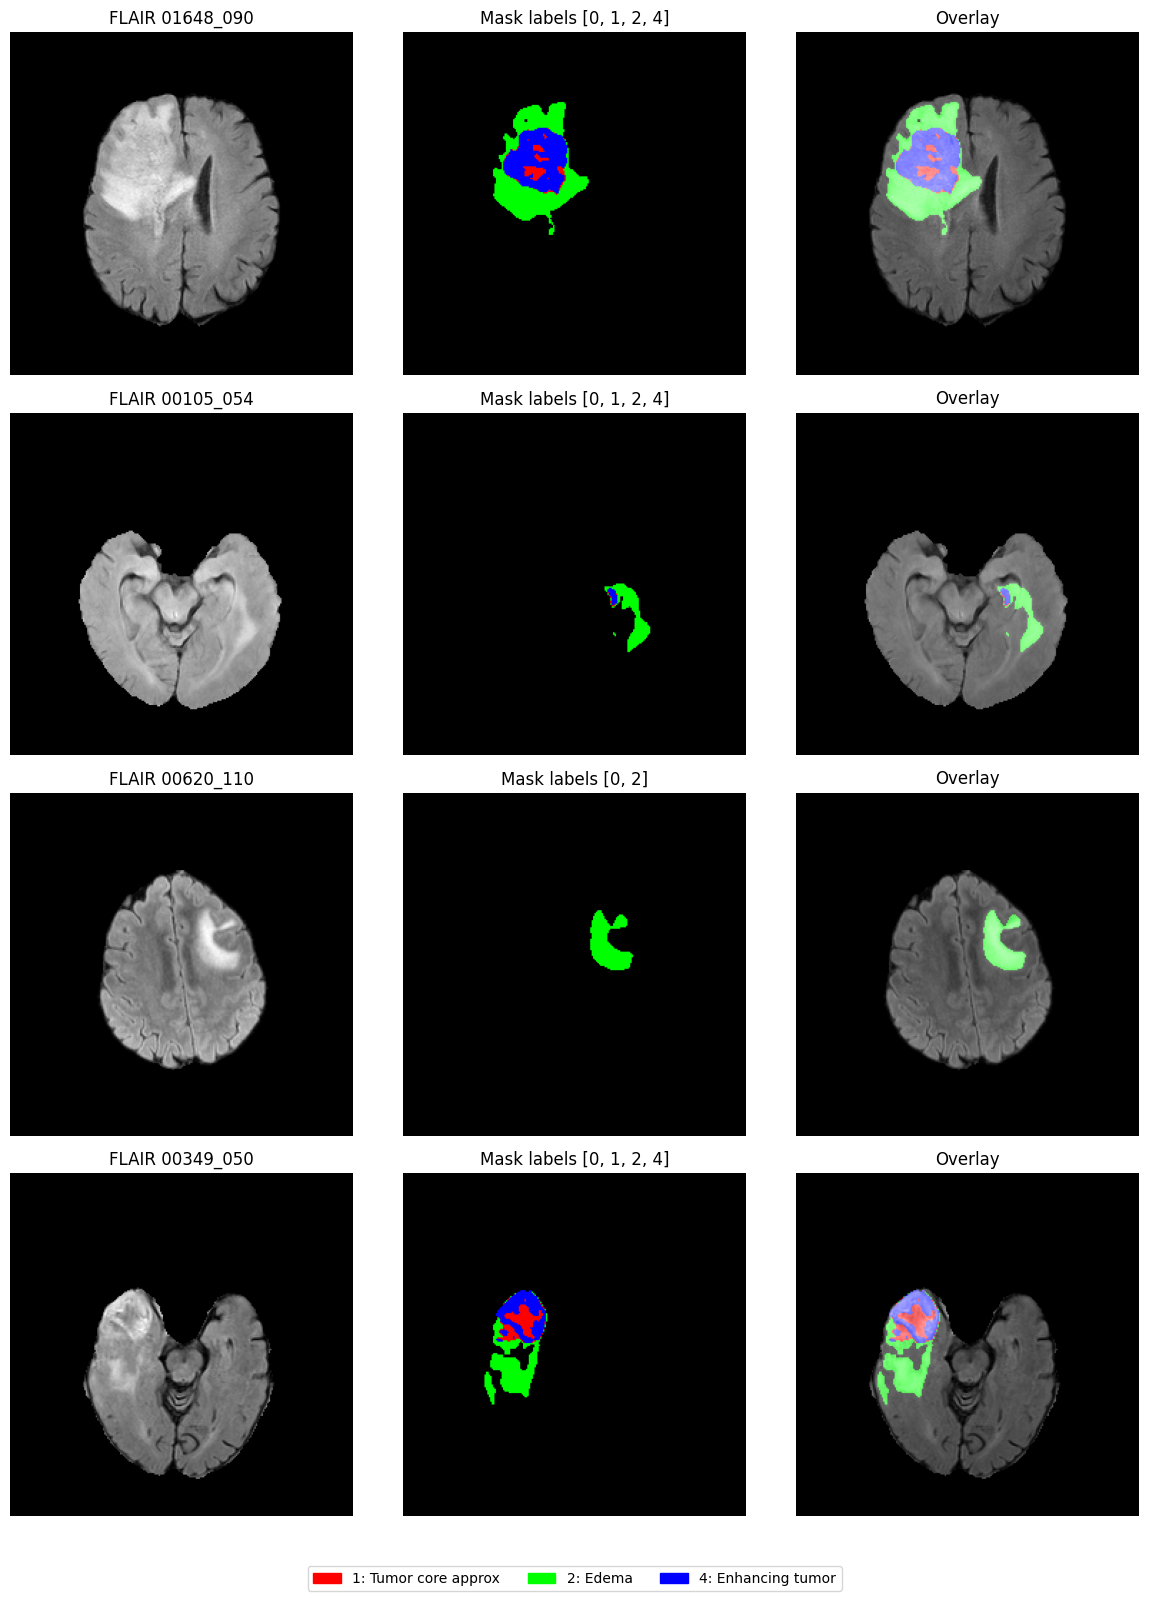

Sample visualization saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/sample_mask_visualization.png


In [ ]:
def mask_to_rgb(mask):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.float32)

    colors = {
        1: [1.0, 0.0, 0.0],  # red
        2: [0.0, 1.0, 0.0],  # green
        4: [0.0, 0.0, 1.0],  # blue
    }

    for label, color in colors.items():
        rgb[mask == label] = color

    return rgb


def normalize_for_display(image):
    image = image.astype(np.float32)
    mn, mx = image.min(), image.max()
    if mx > mn:
        return (image - mn) / (mx - mn)
    return np.zeros_like(image, dtype=np.float32)


def parse_unique_id_from_mask_path(mask_path: Path):
    patient_id, slice_id = mask_path.stem.split("_")
    return patient_id, slice_id


def visualize_random_masks(mask_paths, sample_count=4):
    if not mask_paths:
        print("No masks to visualize.")
        return

    sample_count = min(sample_count, len(mask_paths))
    sampled_paths = random.sample(mask_paths, sample_count)

    fig, axes = plt.subplots(sample_count, 3, figsize=(12, 4 * sample_count))

    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, mask_path in enumerate(sampled_paths):
        patient_id, slice_id = parse_unique_id_from_mask_path(mask_path)

        flair_path = expected_png_path(DATASET_ROOT, "flair", patient_id, slice_id)
        flair = read_grayscale_png(flair_path, IMAGE_SIZE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if flair is None or mask is None:
            continue

        flair_display = normalize_for_display(flair)
        mask_rgb = mask_to_rgb(mask)

        overlay = np.stack([flair_display] * 3, axis=-1)
        overlay = np.clip(0.70 * overlay + 0.55 * mask_rgb, 0, 1)

        axes[row_index, 0].imshow(flair_display, cmap="gray")
        axes[row_index, 0].set_title(f"FLAIR {patient_id}_{slice_id}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(mask_rgb)
        axes[row_index, 1].set_title(f"Mask labels {np.unique(mask).tolist()}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(overlay)
        axes[row_index, 2].set_title("Overlay")
        axes[row_index, 2].axis("off")

    patches = [
        mpatches.Patch(color=[1, 0, 0], label="1: Tumor core approx"),
        mpatches.Patch(color=[0, 1, 0], label="2: Edema"),
        mpatches.Patch(color=[0, 0, 1], label="4: Enhancing tumor"),
    ]

    fig.legend(handles=patches, loc="lower center", ncol=3)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(SAMPLE_FIG_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("Sample visualization saved:", SAMPLE_FIG_PATH)


visualize_random_masks(saved_mask_paths, sample_count=4)


# Final Phase 1 Completion Report

In [ ]:
# @title
saved_mask_paths = sorted(MASK_SAVE_DIR.glob("*.png"))
global_manifest_df = rebuild_global_manifest()

final_report = {
    "finished_at": now_string(),
    "phase": "Phase 1 segmentation mask generation",
    "status": "complete_or_resume_ready",
    "dataset": DATASET_ID,
    "model": HF_REPO_ID,
    "model_revision": HF_REVISION,
    "model_note": "Pretrained MONAI SegResNet BraTS segmentation model, not a locally trained U-Net.",
    "input_channel_order_used": MODEL_MODALITY_ORDER,
    "output_mask_label_mapping": LABEL_NAMES,
    "expected_valid_slices": int(expected_valid_count),
    "saved_mask_files": int(len(saved_mask_paths)),
    "global_manifest_rows": int(len(global_manifest_df)) if len(global_manifest_df) else 0,
    "mask_save_dir": str(MASK_SAVE_DIR),
    "global_manifest_path": str(GLOBAL_MANIFEST_PATH),
    "summary_path": str(SUMMARY_PATH),
    "sample_visualization_path": str(SAMPLE_FIG_PATH),
    "important_warning": (
        "Generated masks are pseudo-labels from a pretrained BraTS model. "
        "They should be visually inspected before Phase 2."
    ),
}

atomic_write_json(LOG_DIR / "final_phase1_report.json", final_report)

print("=" * 80)
print("BrainTumorVQA Phase 1 Report")
print("=" * 80)
print("Status: complete or safely resumable")
print("Model:", HF_REPO_ID)
print("Saved masks:", len(saved_mask_paths))
print("Expected valid slices:", expected_valid_count)
print("Completion:", round(100 * len(saved_mask_paths) / max(expected_valid_count, 1), 2), "%")
print("Mask directory:", MASK_SAVE_DIR)
print("Manifest:", GLOBAL_MANIFEST_PATH)
print("Final report:", LOG_DIR / "final_phase1_report.json")
print("=" * 80)

if len(saved_mask_paths) < expected_valid_count:
    print("\nNot all masks are generated yet.")
    print("This is okay if Colab session stopped or MAX_PATIENTS_PER_RUN was set.")
    print("Rerun from Cell 1. Completed patients and existing masks will be skipped.")
else:
    print("\nAll expected valid masks appear to be generated.")
    print("You can now use MASK_SAVE_DIR in Phase 2.")


Global manifest rebuilt: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/global_mask_manifest.csv
Rows: 79864
BrainTumorVQA Phase 1 Report
Status: complete or safely resumable
Model: MONAI/brats_mri_segmentation
Saved masks: 79864
Expected valid slices: 79864
Completion: 100.0 %
Mask directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d
Manifest: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/global_mask_manifest.csv
Final report: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/final_phase1_report.json

All expected valid masks appear to be generated.
You can now use MASK_SAVE_DIR in Phase 2.


# ============================================================
# BrainTumorVQA Phase 2A
# Segmentation-Mask-Guided Region Token Generation
# Tokens: edema, NCR/NET, enhancing, tumor, context, global
# ============================================================

## Showing the overlay images of MRI with segmentation mask

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root: /content/rsna_brats_2021_2d_extracted
Local mask: /content/00006_077_mask.png
Raw save dir: /content/drive/MyDrive/AUGR_VQA_figure_assets/raw_mri
Overlay save dir: /content/drive/MyDrive/AUGR_VQA_figure_assets/mask_overlay
Mask unique values: [0 1 2 4]
Non-background pixels: 3293

Saved raw MRI images:
/content/drive/MyDrive/AUGR_VQA_figure_assets/raw_mri/00006_077_flair_raw_mri.png
/content/drive/MyDrive/AUGR_VQA_figure_assets/raw_mri/00006_077_t1_raw_mri.png
/content/drive/MyDrive/AUGR_VQA_figure_assets/raw_mri/00006_077_t1ce_raw_mri.png
/content/drive/MyDrive/AUGR_VQA_figure_assets/raw_mri/00006_077_t2_raw_mri.png

Saved mask overlay images:
/content/drive/MyDrive/AUGR_VQA_figure_assets/mask_overlay/00006_077_flair_mask_overlay.png
/content/drive/MyDrive/AUGR_VQA_figure_assets/mask_overlay/00006_077_t1_mask_overlay.png
/content/drive/MyDrive/

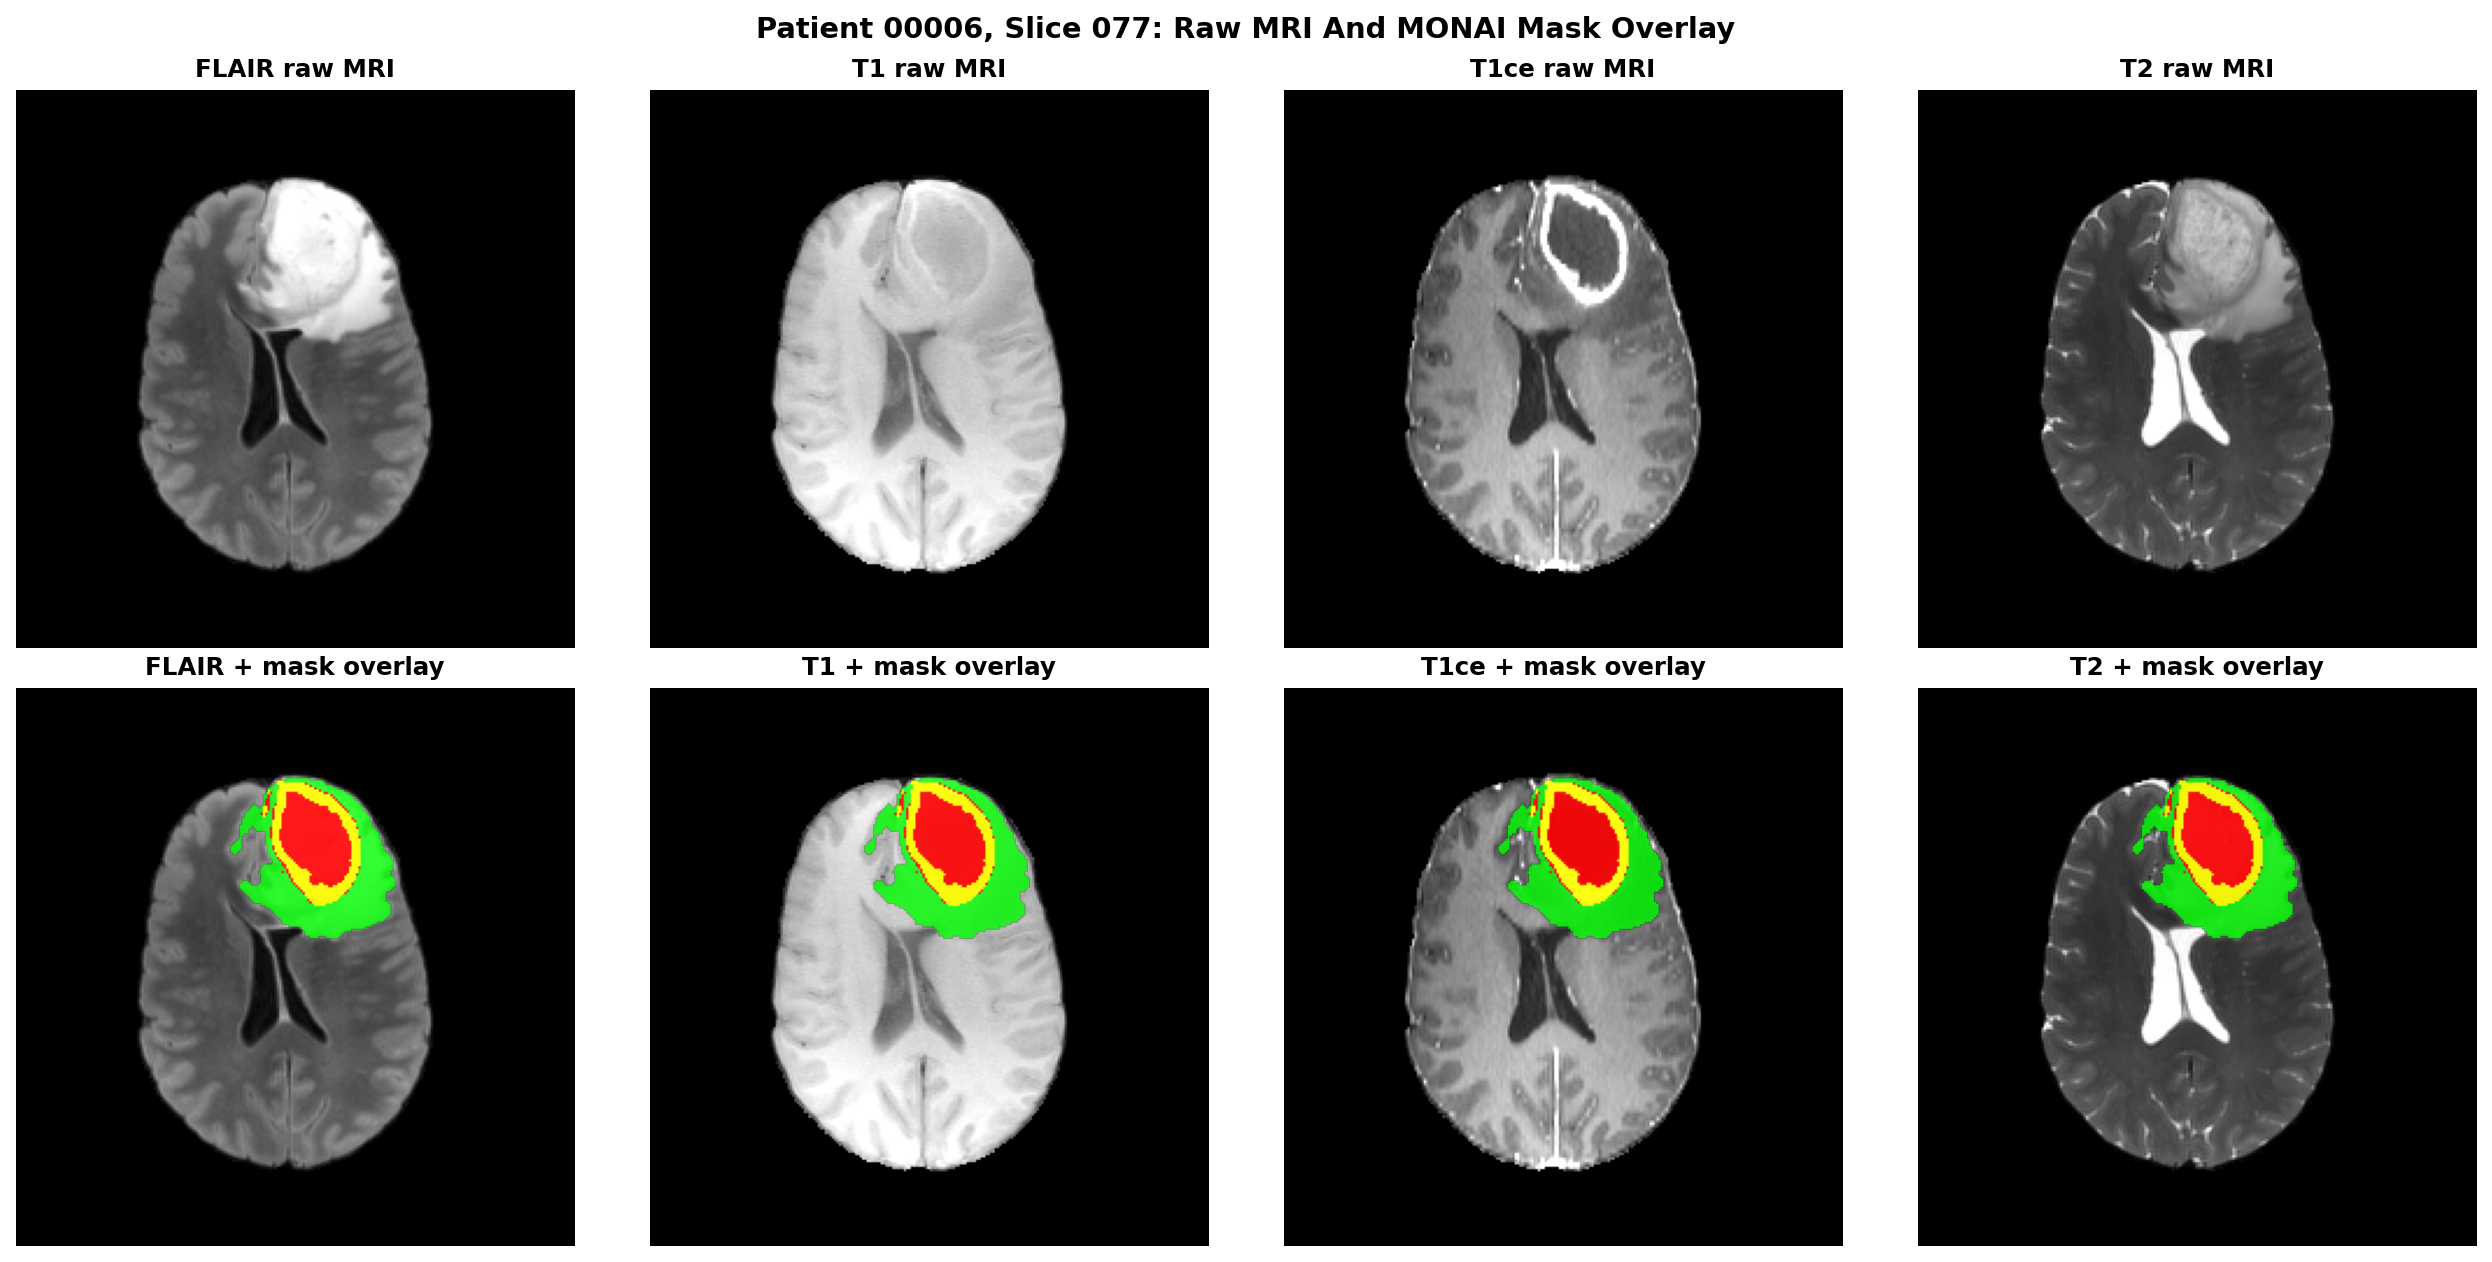

In [5]:
from pathlib import Path
import zipfile
import shutil
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

# drive.mount("/content/drive")

PATIENT_ID = "00006"
SLICE_ID = "077"

PROJECT_DRIVE_DIR = PROJECT_ROOT
PHASE1_DIR = PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats"
DATASET_ZIP = PHASE1_DIR / "dataset_cache" / "rsnabrats20212d.zip"
DATASET_EXTRACT_DIR = TEMP_DIR / "rsna_brats_2021_2d_extracted")
MASK_DIR_STR = str(PHASE1_DIR / "generated_masks_rsna_2d")

SAVE_DIR = PROJECT_DRIVE_DIR / "phase_7" / "p7b_augr_vqa_qualitative_case_figure" / "figure_assets"
RAW_SAVE_DIR = SAVE_DIR / "raw_mri"
OVERLAY_SAVE_DIR = SAVE_DIR / "mask_overlay"

RAW_SAVE_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_SAVE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_MASK = Path(f"{TEMP_DIR}/{PATIENT_ID}_{SLICE_ID}_mask.png")

DATASET_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
if not any(DATASET_EXTRACT_DIR.iterdir()):
    with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
        zf.extractall(DATASET_EXTRACT_DIR)

dataset_root = None
for p in [DATASET_EXTRACT_DIR] + [x for x in DATASET_EXTRACT_DIR.rglob("*") if x.is_dir()]:
    if all((p / m).is_dir() for m in ["flair", "t1", "t1ce", "t2"]):
        dataset_root = p
        break

if dataset_root is None:
    raise FileNotFoundError("Could not find folders: flair, t1, t1ce, t2 inside extracted zip.")

modalities = {
    "FLAIR": dataset_root / "flair" / f"flair_BraTS2021_{PATIENT_ID}_{SLICE_ID}.png",
    "T1": dataset_root / "t1" / f"t1_BraTS2021_{PATIENT_ID}_{SLICE_ID}.png",
    "T1ce": dataset_root / "t1ce" / f"t1ce_BraTS2021_{PATIENT_ID}_{SLICE_ID}.png",
    "T2": dataset_root / "t2" / f"t2_BraTS2021_{PATIENT_ID}_{SLICE_ID}.png",
}

missing_modalities = [str(p) for p in modalities.values() if not p.exists()]
if missing_modalities:
    raise FileNotFoundError("Missing modality files:\n" + "\n".join(missing_modalities))

drive_mask_str = f"{MASK_DIR_STR}/{PATIENT_ID}_{SLICE_ID}.png"

if not LOCAL_MASK.exists():
    last_err = None
    for attempt in range(5):
        try:
            shutil.copyfile(drive_mask_str, str(LOCAL_MASK))
            break
        except OSError as e:
            last_err = e
            print(f"Drive mask copy failed attempt {attempt + 1}/5: {e}")
            time.sleep(2)
    else:
        raise OSError(
            f"Could not copy mask from Drive after retries:\n{drive_mask_str}\n"
            "Try remounting Drive with force_remount=True, then rerun this cell."
        ) from last_err

def load_gray(path):
    return np.array(Image.open(path).convert("L"))

def normalize_for_display(arr):
    arr = arr.astype(np.float32)
    lo, hi = np.percentile(arr, [1, 99])
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)

mask = np.array(Image.open(LOCAL_MASK))
if mask.ndim == 3:
    mask = mask[..., 0]
mask = mask.astype(np.uint8)

print("Dataset root:", dataset_root)
print("Local mask:", LOCAL_MASK)
print("Raw save dir:", RAW_SAVE_DIR)
print("Overlay save dir:", OVERLAY_SAVE_DIR)
print("Mask unique values:", np.unique(mask))
print("Non-background pixels:", int((mask > 0).sum()))

rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
rgba[mask == 1] = (1.00, 0.00, 0.00, 0.90)  # red
rgba[mask == 2] = (0.00, 1.00, 0.00, 0.80)  # green
rgba[mask == 4] = (1.00, 1.00, 0.00, 0.92)  # yellow

raw_saved_paths = []
overlay_saved_paths = []

for name, path in modalities.items():
    img_raw = load_gray(path)
    img_display = normalize_for_display(img_raw)

    # Save raw MRI as display-ready grayscale PNG
    raw_out_path = RAW_SAVE_DIR / f"{PATIENT_ID}_{SLICE_ID}_{name.lower()}_raw_mri.png"
    Image.fromarray((img_display * 255).astype(np.uint8)).save(raw_out_path)
    raw_saved_paths.append(raw_out_path)

    # Save mask overlay image
    fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
    ax.imshow(img_display, cmap="gray")
    ax.imshow(rgba)
    ax.axis("off")

    overlay_out_path = OVERLAY_SAVE_DIR / f"{PATIENT_ID}_{SLICE_ID}_{name.lower()}_mask_overlay.png"
    fig.savefig(overlay_out_path, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    overlay_saved_paths.append(overlay_out_path)

print("\nSaved raw MRI images:")
for p in raw_saved_paths:
    print(p)

print("\nSaved mask overlay images:")
for p in overlay_saved_paths:
    print(p)

# Optional preview in notebook output
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=160)

for ax, (name, path) in zip(axes[0], modalities.items()):
    img = normalize_for_display(load_gray(path))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{name} raw MRI", fontsize=11, fontweight="bold")
    ax.axis("off")

for ax, (name, path) in zip(axes[1], modalities.items()):
    img = normalize_for_display(load_gray(path)) 
    ax.imshow(img, cmap="gray")
    ax.imshow(rgba)
    ax.set_title(f"{name} + mask overlay", fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle(
    f"Patient {PATIENT_ID}, Slice {SLICE_ID}: Raw MRI And MONAI Mask Overlay",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
